In [3]:
from collections import defaultdict
from pathlib import Path
import pandas as pd
import os
import re

# Paths
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/ECOBICI"
WAREHOUSE = f"{BASE_PATH}/warehouse"
os.makedirs(WAREHOUSE, exist_ok=True)

# Función para normalizar columnas
def normalizar_df(df, year):
    df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

    def get_col(posibles):
        for p in posibles:
            if p in df.columns:
                return df[p]
        return pd.Series([None] * len(df))

    genero = get_col(["genero_usuario", "genero", "genero_usuario.1"])
    edad = get_col(["edad_usuario", "edad", "edad_usuario.1"])
    bici = get_col(["bici", "bikeid"])

    est_retiro = get_col(["ciclo_estacion_retiro", "ce_retiro"])
    est_arribo = get_col(["ciclo_estacion_arribo", "ce_arribo", "ciclo_estacionarribo"])

    fecha_ret = get_col(["fecha_retiro", "fecha_retiro.1", "fecha_retiro.2"])
    hora_ret = get_col(["hora_retiro", "hora_retiro.1"])

    fecha_arr = get_col(["fecha_arribo", "fecha_arribo.1", "fecha_arribo.2", "fecha_arribo_"])
    hora_arr = get_col(["hora_arribo", "hora_arribo.1"])

    # Convertir fechas
    fecha_ret = fecha_ret.astype(str)
    hora_ret = hora_ret.astype(str)
    fecha_arr = fecha_arr.astype(str)
    hora_arr = hora_arr.astype(str)

    def combinar_fecha_hora(fecha_col, hora_col):
        return pd.to_datetime(
            fecha_col.str.strip() + " " + hora_col.str.strip(),
            errors="coerce",
            dayfirst=True
        )

    fecha_hora_retiro = combinar_fecha_hora(fecha_ret, hora_ret)
    fecha_hora_arribo = combinar_fecha_hora(fecha_arr, hora_arr)

    return pd.DataFrame({
        "anio": int(year),
        "genero": genero.astype(str),
        "edad": pd.to_numeric(edad, errors='coerce'),
        "bici_id": bici.astype(str),
        "estacion_retiro": est_retiro.astype(str),
        "estacion_arribo": est_arribo.astype(str),
        "fecha_hora_retiro": fecha_hora_retiro,
        "fecha_hora_arribo": fecha_hora_arribo
    })


In [4]:
import gc  # Garbage Collector

# Paso 1: Obtener archivos por año
csv_files = sorted(Path(BASE_PATH).glob("*.csv"))
files_by_year = defaultdict(list)
pattern = re.compile(r"(\d{4})-\d{2}")
for file in csv_files:
    match = pattern.match(file.stem)
    if match:
        year = match.group(1)
        files_by_year[year].append(file)

# Paso 2: Procesar año por año y guardar
for year in sorted(files_by_year.keys()):
    print(f"Procesando {year}...")
    try:
        dfs = [pd.read_csv(file, low_memory=False) for file in files_by_year[year]]
        df = pd.concat(dfs, ignore_index=True)

        df_clean = normalizar_df(df, int(year))

        output_path = f"{WAREHOUSE}/ecobici_{year}.parquet"
        df_clean.to_parquet(output_path, index=False)
        print(f"Guardado: {output_path} ({len(df_clean)} registros)")

        # Limpiar RAM
        del df, dfs, df_clean
        gc.collect()

    except Exception as e:
        print(f"Error en {year}: {e}")


Procesando 2013...
Guardado: /content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse/ecobici_2013.parquet (6515328 registros)
Procesando 2014...
Guardado: /content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse/ecobici_2014.parquet (7952247 registros)
Procesando 2015...
Guardado: /content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse/ecobici_2015.parquet (9192076 registros)
Procesando 2016...
Guardado: /content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse/ecobici_2016.parquet (9069543 registros)
Procesando 2017...
Guardado: /content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse/ecobici_2017.parquet (9498044 registros)
Procesando 2018...
Guardado: /content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse/ecobici_2018.parquet (8540258 registros)
Procesando 2019...
Guardado: /content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse/ecobici_2019.parquet (8415445 registros)
Procesando 2020...
Guardado: /content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse/ecobici_2020.parquet (403

In [5]:
!pip install pyarrow


In [1]:
import gc
import pandas as pd

gc.collect()


0

In [7]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd
from pathlib import Path
import gc

WAREHOUSE = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse"
OUTPUT = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/ecobici_2013_2025.parquet"

# Años válidos confirmados
anios_validos = [
    "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020",
    "2023", "2025"
]

# Crear un writer de Parquet vacío
writer = None

for anio in anios_validos:
    archivo = Path(WAREHOUSE) / f"ecobici_{anio}.parquet"
    print(f"📥 Procesando {archivo.name}...")

    try:
        df = pd.read_parquet(archivo)
        table = pa.Table.from_pandas(df)

        if writer is None:
            writer = pq.ParquetWriter(OUTPUT, table.schema)

        writer.write_table(table)
        del df, table
        gc.collect()
        print(f"✅ Añadido {anio} ({archivo.name})")

    except Exception as e:
        print(f"❌ Error al procesar {anio}: {e}")

# Cerrar el writer si se usó
if writer:
    writer.close()
    print(f"\n🎯 Archivo combinado guardado en: {OUTPUT}")
else:
    print("⚠️ No se pudo crear el archivo combinado.")


📥 Procesando ecobici_2013.parquet...
✅ Añadido 2013 (ecobici_2013.parquet)
📥 Procesando ecobici_2014.parquet...
✅ Añadido 2014 (ecobici_2014.parquet)
📥 Procesando ecobici_2015.parquet...
✅ Añadido 2015 (ecobici_2015.parquet)
📥 Procesando ecobici_2016.parquet...
✅ Añadido 2016 (ecobici_2016.parquet)
📥 Procesando ecobici_2017.parquet...
✅ Añadido 2017 (ecobici_2017.parquet)
📥 Procesando ecobici_2018.parquet...
✅ Añadido 2018 (ecobici_2018.parquet)
📥 Procesando ecobici_2019.parquet...
✅ Añadido 2019 (ecobici_2019.parquet)
📥 Procesando ecobici_2020.parquet...
❌ Error al procesar 2020: Table schema does not match schema used to create file: 
table:
anio: int64
genero: string
edad: double
bici_id: string
estacion_retiro: string
estacion_arribo: string
fecha_hora_retiro: timestamp[ns]
fecha_hora_arribo: timestamp[ns]
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 1251 vs. 
file:
anio: int64
genero: string
edad: int64
bici_id: string
estacion

In [8]:
import pyarrow.parquet as pq
import pyarrow as pa
import pandas as pd
from pathlib import Path
import gc

WAREHOUSE = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse"
OUTPUT = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/ecobici_2013_2025.parquet"

anios_validos = [
    "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020",
    "2023", "2025"
]

writer = None

for anio in anios_validos:
    archivo = Path(WAREHOUSE) / f"ecobici_{anio}.parquet"
    print(f"📥 Procesando {archivo.name}...")

    try:
        df = pd.read_parquet(archivo)

        # Forzar el tipo float64 para evitar conflictos de esquema
        df["edad"] = pd.to_numeric(df["edad"], errors="coerce").astype("float64")

        table = pa.Table.from_pandas(df)

        if writer is None:
            writer = pq.ParquetWriter(OUTPUT, table.schema)

        writer.write_table(table)
        del df, table
        gc.collect()
        print(f"✅ Añadido {anio} ({archivo.name})")

    except Exception as e:
        print(f"❌ Error al procesar {anio}: {e}")

if writer:
    writer.close()
    print(f"\n🎯 Archivo combinado guardado en: {OUTPUT}")
else:
    print("⚠️ No se pudo crear el archivo combinado.")


📥 Procesando ecobici_2013.parquet...
✅ Añadido 2013 (ecobici_2013.parquet)
📥 Procesando ecobici_2014.parquet...
✅ Añadido 2014 (ecobici_2014.parquet)
📥 Procesando ecobici_2015.parquet...
✅ Añadido 2015 (ecobici_2015.parquet)
📥 Procesando ecobici_2016.parquet...
✅ Añadido 2016 (ecobici_2016.parquet)
📥 Procesando ecobici_2017.parquet...
✅ Añadido 2017 (ecobici_2017.parquet)
📥 Procesando ecobici_2018.parquet...
✅ Añadido 2018 (ecobici_2018.parquet)
📥 Procesando ecobici_2019.parquet...
✅ Añadido 2019 (ecobici_2019.parquet)
📥 Procesando ecobici_2020.parquet...
✅ Añadido 2020 (ecobici_2020.parquet)
📥 Procesando ecobici_2023.parquet...
✅ Añadido 2023 (ecobici_2023.parquet)
📥 Procesando ecobici_2025.parquet...
✅ Añadido 2025 (ecobici_2025.parquet)

🎯 Archivo combinado guardado en: /content/drive/MyDrive/Colab Notebooks/ECOBICI/ecobici_2013_2025.parquet


In [ ]:
import pandas as pd
import gc

# Cargar solo columnas necesarias
archivo_parquet = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/ecobici_2013_2025.parquet"
cols_usar = ['edad', 'fecha_hora_retiro']
df = pd.read_parquet(archivo_parquet, columns=cols_usar)

# Transformar variables de fecha a variables continuas
df['hora'] = df['fecha_hora_retiro'].dt.hour + df['fecha_hora_retiro'].dt.minute / 60.0
df['dia_semana'] = df['fecha_hora_retiro'].dt.weekday
df['mes'] = df['fecha_hora_retiro'].dt.month

# Eliminar nulos y outliers de edad
df = df[df['edad'].between(10, 100)]
df = df.dropna(subset=['edad', 'hora', 'dia_semana', 'mes'])

# Seleccionar variables finales para clustering
X = df[['edad', 'hora', 'dia_semana', 'mes']].copy()

# Limpieza para liberar RAM
del df
gc.collect()

print(X.sample(5))
print(f"Variables preparadas. Forma final: {X.shape}")


In [1]:
!pip install pyarrow --quiet


In [2]:
import pandas as pd
import pyarrow.parquet as pq
import gc
from pathlib import Path

# Ruta de entrada y salida
INPUT_PARQUET = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/ecobici_2013_2025.parquet"
CHUNKS_FOLDER = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/chunks_transformados"
Path(CHUNKS_FOLDER).mkdir(parents=True, exist_ok=True)

# Tamaño de chunk: ajustar si sigues teniendo problemas de RAM
CHUNK_SIZE = 500_000
chunk_idx = 0

# Leer parquet como ArrowTable (no como DataFrame completo)
dataset = pq.ParquetFile(INPUT_PARQUET)

# Iterar por lotes (row groups o por rangos)
row_groups = dataset.num_row_groups

for rg in range(row_groups):
    print(f"📦 Procesando row group {rg + 1}/{row_groups}")

    # Leer row group como DataFrame
    df = dataset.read_row_group(rg).to_pandas()

    # ✨ Transformaciones
    df['hora'] = df['fecha_hora_retiro'].dt.hour + df['fecha_hora_retiro'].dt.minute / 60.0
    df['dia_semana'] = df['fecha_hora_retiro'].dt.weekday
    df['mes'] = df['fecha_hora_retiro'].dt.month

    # Limpiar edad y nulos
    df = df[df['edad'].between(10, 100)]
    df = df.dropna(subset=['edad', 'hora', 'dia_semana', 'mes'])

    # Solo columnas necesarias para clustering
    X_chunk = df[['edad', 'hora', 'dia_semana', 'mes']].copy()

    # Guardar chunk transformado (opcional pero recomendado)
    output_chunk = Path(CHUNKS_FOLDER) / f"chunk_{chunk_idx:03d}.parquet"
    X_chunk.to_parquet(output_chunk, index=False)
    print(f"✅ Guardado {output_chunk.name} con {len(X_chunk)} filas")

    # Limpiar memoria
    del df, X_chunk
    gc.collect()
    chunk_idx += 1

print("🎯 Transformación por chunks completada.")


📦 Procesando row group 1/84
✅ Guardado chunk_000.parquet con 464833 filas
📦 Procesando row group 2/84
✅ Guardado chunk_001.parquet con 391171 filas
📦 Procesando row group 3/84
✅ Guardado chunk_002.parquet con 452526 filas
📦 Procesando row group 4/84
✅ Guardado chunk_003.parquet con 418952 filas
📦 Procesando row group 5/84
✅ Guardado chunk_004.parquet con 319419 filas
📦 Procesando row group 6/84
✅ Guardado chunk_005.parquet con 550013 filas
📦 Procesando row group 7/84
✅ Guardado chunk_006.parquet con 2 filas
📦 Procesando row group 8/84
✅ Guardado chunk_007.parquet con 460590 filas
📦 Procesando row group 9/84
✅ Guardado chunk_008.parquet con 297040 filas
📦 Procesando row group 10/84
✅ Guardado chunk_009.parquet con 533494 filas
📦 Procesando row group 11/84
✅ Guardado chunk_010.parquet con 445350 filas
📦 Procesando row group 12/84
✅ Guardado chunk_011.parquet con 330272 filas
📦 Procesando row group 13/84
✅ Guardado chunk_012.parquet con 541114 filas
📦 Procesando row group 14/84
✅ Guardado

In [4]:
import pandas as pd
import gc
from pathlib import Path

WAREHOUSE = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/warehouse"

# Años que sí procesaron correctamente
anios_validos = [
    "2013", "2014", "2015", "2016", "2017", "2018", "2019",
    "2020", "2023", "2025"
]

data_chunks = []

for anio in anios_validos:
    archivo = Path(WAREHOUSE) / f"ecobici_{anio}.parquet"
    print(f"📥 Procesando {archivo.name}...")

    try:
        df = pd.read_parquet(archivo)

        # Filtrar y transformar
        df = df[df['edad'].between(10, 100)]
        df = df.dropna(subset=['edad', 'fecha_hora_retiro'])

        df['hora'] = df['fecha_hora_retiro'].dt.hour + df['fecha_hora_retiro'].dt.minute / 60.0
        df['dia_semana'] = df['fecha_hora_retiro'].dt.weekday
        df['mes'] = df['fecha_hora_retiro'].dt.month

        # Solo las columnas necesarias para clustering
        chunk_features = df[['edad', 'hora', 'dia_semana', 'mes']].copy()
        data_chunks.append(chunk_features)

        # Limpiar memoria
        del df, chunk_features
        gc.collect()

        print(f"✅ Procesado {anio} ({len(data_chunks[-1])} registros)")

    except Exception as e:
        print(f"❌ Error en {anio}: {e}")

# Combinar todos los años
df_final = pd.concat(data_chunks, ignore_index=True)
print(f"\n🎯 Dataset final para clustering listo: {df_final.shape[0]} registros")


📥 Procesando ecobici_2013.parquet...


<ipython-input-4-2e7797923360>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hora'] = df['fecha_hora_retiro'].dt.hour + df['fecha_hora_retiro'].dt.minute / 60.0


✅ Procesado 2013 (2596916 registros)
📥 Procesando ecobici_2014.parquet...
✅ Procesado 2014 (3175829 registros)
📥 Procesando ecobici_2015.parquet...
✅ Procesado 2015 (3579096 registros)
📥 Procesando ecobici_2016.parquet...
✅ Procesado 2016 (2052057 registros)
📥 Procesando ecobici_2017.parquet...
✅ Procesado 2017 (9497104 registros)
📥 Procesando ecobici_2018.parquet...
✅ Procesado 2018 (8539760 registros)
📥 Procesando ecobici_2019.parquet...
✅ Procesado 2019 (8415424 registros)
📥 Procesando ecobici_2020.parquet...
✅ Procesado 2020 (4031896 registros)
📥 Procesando ecobici_2023.parquet...
✅ Procesado 2023 (12177337 registros)
📥 Procesando ecobici_2025.parquet...
✅ Procesado 2025 (7115353 registros)

🎯 Dataset final para clustering listo: 61180772 registros


In [ ]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# Ruta del archivo
archivo_parquet = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/ecobici_2013_2025.parquet"
batch_size = 2_000_000

# Inicializar lista para datos
X_all = []

# Leer en batches con PyArrow
print("📦 Iniciando lectura por batches...")
reader = pq.ParquetFile(archivo_parquet)
for batch in reader.iter_batches(batch_size=batch_size):
    df = batch.to_pandas()

    # Limpiar y transformar
    df = df[df['edad'].between(10, 100)]
    df = df.dropna(subset=['edad', 'fecha_hora_retiro'])

    df['hora'] = df['fecha_hora_retiro'].dt.hour + df['fecha_hora_retiro'].dt.minute / 60.0
    df['dia_semana'] = df['fecha_hora_retiro'].dt.weekday
    df['mes'] = df['fecha_hora_retiro'].dt.month

    df_final = df[['edad', 'hora', 'dia_semana', 'mes']].copy()
    X_all.append(df_final)

    print(f"✅ Procesado batch de {len(df_final)} registros")
    del df, df_final, batch
    gc.collect()

# Concatenar todos los chunks
X_total = pd.concat(X_all, ignore_index=True)
print(f"📊 Total registros para clustering: {X_total.shape[0]}")
del X_all
gc.collect()

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_total)

# Entrenar modelo KMeans con 3 clusters
print("🔍 Entrenando modelo KMeans (3 clusters)...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

# Agregar etiquetas
X_total['cluster'] = labels

print("✅ Clustering finalizado.")

# Visualización: Edad vs Hora
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_total.sample(10000), x="edad", y="hora", hue="cluster", palette="Set2", alpha=0.6)
plt.title("Clustering ECOBICI: Edad vs Hora")
plt.xlabel("Edad")
plt.ylabel("Hora del día")
plt.grid(True)
plt.show()


📦 Iniciando lectura por batches...


<ipython-input-6-7bb2b5b4f517>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hora'] = df['fecha_hora_retiro'].dt.hour + df['fecha_hora_retiro'].dt.minute / 60.0


✅ Procesado batch de 856004 registros
✅ Procesado batch de 677874 registros
✅ Procesado batch de 846094 registros


<ipython-input-6-7bb2b5b4f517>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hora'] = df['fecha_hora_retiro'].dt.hour + df['fecha_hora_retiro'].dt.minute / 60.0
<ipython-input-6-7bb2b5b4f517>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dia_semana'] = df['fecha_hora_retiro'].dt.weekday
<ipython-input-6-7bb2b5b4f517>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

✅ Procesado batch de 805406 registros


...

✅ Procesado batch de 877202 registros
✅ Procesado batch de 618733 registros


<ipython-input-6-7bb2b5b4f517>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hora'] = df['fecha_hora_retiro'].dt.hour + df['fecha_hora_retiro'].dt.minute / 60.0
<ipython-input-6-7bb2b5b4f517>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dia_semana'] = df['fecha_hora_retiro'].dt.weekday
<ipython-input-6-7bb2b5b4f517>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

✅ Procesado batch de 897449 registros
✅ Procesado batch de 721486 registros
✅ Procesado batch de 881526 registros


<ipython-input-6-7bb2b5b4f517>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hora'] = df['fecha_hora_retiro'].dt.hour + df['fecha_hora_retiro'].dt.minute / 60.0
<ipython-input-6-7bb2b5b4f517>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dia_semana'] = df['fecha_hora_retiro'].dt.weekday
<ipython-input-6-7bb2b5b4f517>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

✅ Procesado batch de 831350 registros
✅ Procesado batch de 716041 registros
✅ Procesado batch de 275955 registros
✅ Procesado batch de 0 registros
✅ Procesado batch de 1270588 registros
✅ Procesado batch de 1999766 registros
✅ Procesado batch de 1999842 registros
✅ Procesado batch de 1999832 registros
✅ Procesado batch de 1999853 registros
✅ Procesado batch de 1999800 registros
✅ Procesado batch de 1999846 registros
✅ Procesado batch de 1999876 registros
✅ Procesado batch de 1999965 registros
✅ Procesado batch de 2000000 registros
✅ Procesado batch de 1999998 registros
✅ Procesado batch de 1999991 registros
✅ Procesado batch de 1999995 registros
✅ Procesado batch de 1999995 registros
✅ Procesado batch de 1999989 registros
✅ Procesado batch de 1999921 registros
✅ Procesado batch de 1999899 registros
✅ Procesado batch de 1999991 registros
✅ Procesado batch de 1999987 registros
✅ Procesado batch de 1999979 registros
✅ Procesado batch de 1999984 registros
✅ Procesado batch de 1999915 regis

In [4]:
batches = []


In [6]:
import pandas as pd
import pyarrow.parquet as pq

archivo_parquet = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/ecobici_consolidado.parquet"

batch_size = 2_000_000
batches = []

# Abrir dataset parquet por partes
parquet_file = pq.ParquetFile(archivo_parquet)
total_rows = parquet_file.metadata.num_rows

print("📦 Iniciando lectura por batches...")

for start in range(0, total_rows, batch_size):
    end = min(start + batch_size, total_rows)
    df = parquet_file.read_row_group(start // batch_size).to_pandas(columns=["edad", "fecha_hora_retiro"])

    # Transformaciones necesarias
    df['fecha_hora_retiro'] = pd.to_datetime(df['fecha_hora_retiro'], errors='coerce')
    df = df.dropna(subset=['fecha_hora_retiro'])
    df['hora'] = df['fecha_hora_retiro'].dt.hour + df['fecha_hora_retiro'].dt.minute / 60.0
    df['dia_semana'] = df['fecha_hora_retiro'].dt.weekday
    df['mes'] = df['fecha_hora_retiro'].dt.month

    # Guardar batch transformado
    df_transformado = df[['edad', 'hora', 'dia_semana', 'mes']].copy()
    batches.append(df_transformado)

    print(f"✅ Procesado batch de {len(df)} registros")

# Concatenar todos los batches para clustering
X_total = pd.concat(batches, ignore_index=True)
print(f"📊 Total registros para clustering: {len(X_total)}")


FileNotFoundError: [Errno 2] Failed to open local file '/content/drive/MyDrive/Colab Notebooks/ECOBICI/ecobici_consolidado.parquet'. Detail: [errno 2] No such file or directory

In [7]:
import os

ruta = "/content/drive/MyDrive/Colab Notebooks/ECOBICI"
archivos = os.listdir(ruta)
print("📂 Archivos disponibles en ECOBICI:")
for archivo in archivos:
    print("-", archivo)


📂 Archivos disponibles en ECOBICI:
- 2014-06.csv
- 2014-01.csv
- 2014-04.csv
- 2014-02.csv
- 2014-05.csv
- 2014-03.csv
- 2014-08.csv
- 2014-09.csv
- 2014-12.csv
- 2014-07.csv
- 2014-11.csv
- 2014-10.csv
- 2015-01.csv
- 2015-02.csv
- 2015-03.csv
- 2015-04.csv
- 2015-05.csv
- 2015-06.csv
- 2015-07.csv
- 2015-12.csv
- 2015-09.csv
- 2015-08.csv
- 2015-11.csv
- 2015-10.csv
- 2016-01.csv
- 2016-02.csv
- 2016-03.csv
- 2016-05.csv
- 2016-06.csv
- 2016-04.csv
- 2016-07.csv
- 2016-09.csv
- 2016-11.csv
- 2016-08.csv
- 2016-12.csv
- 2016-10.csv
- 2017-04.csv
- 2017-02.csv
- 2017-01.csv
- 2017-03.csv
- 2017-05.csv
- 2017-06.csv
- 2017-07.csv
- 2017-12.csv
- 2017-09.csv
- 2017-11.csv
- 2017-08.csv
- 2017-10.csv
- 2018-01.csv
- 2018-02.csv
- 2018-06.csv
- 2018-03.csv
- 2018-04.csv
- 2018-05.csv
- 2018-12.csv
- 2018-11.csv
- 2018-09.csv
- 2018-07.csv
- 2018-08.csv
- 2018-10.csv
- 2019-02.csv
- 2019-01.csv
- 2019-04.csv
- 2019-06.csv
- 2019-05.csv
- 2019-03.csv
- 2019-12.csv
- 2019-09.csv
- 2019-07.csv

In [10]:
# Ver columnas disponibles en el primer row_group
df_preview = parquet_file.read_row_group(0).to_pandas()
print(df_preview.columns.tolist())


['anio', 'genero', 'edad', 'bici_id', 'estacion_retiro', 'estacion_arribo', 'fecha_hora_retiro', 'fecha_hora_arribo']


<ipython-input-11-64b125886d10>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hora'] = df['fecha_hora_retiro'].dt.hour
<ipython-input-11-64b125886d10>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dia_semana'] = df['fecha_hora_retiro'].dt.weekday  # 0=lunes, 6=domingo
<ipython-input-11-64b125886d10>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

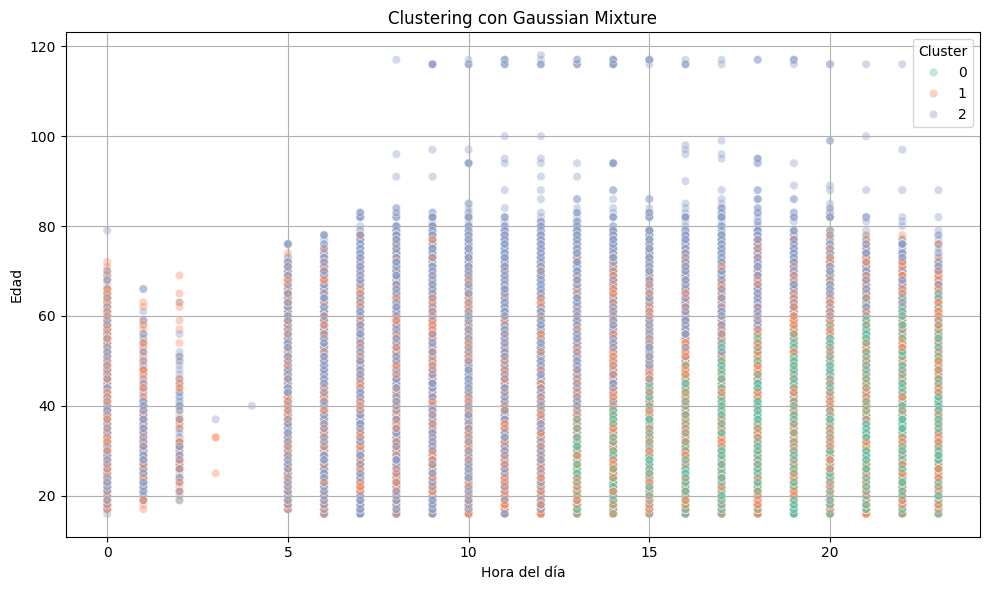

In [11]:
import pandas as pd
import pyarrow.parquet as pq
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# Ruta del archivo Parquet
archivo_parquet = "/content/drive/MyDrive/Colab Notebooks/ECOBICI/ecobici_2013_2025.parquet"

# Leer archivo parquet
parquet_file = pq.ParquetFile(archivo_parquet)
total_row_groups = parquet_file.num_row_groups

batches = []

for i in range(total_row_groups):
    df = parquet_file.read_row_group(i).to_pandas()

    # Convertir a datetime
    df['fecha_hora_retiro'] = pd.to_datetime(df['fecha_hora_retiro'], errors='coerce')

    # Filtrar nulos
    df = df.dropna(subset=['fecha_hora_retiro', 'edad'])

    # Extraer variables
    df['hora'] = df['fecha_hora_retiro'].dt.hour
    df['dia_semana'] = df['fecha_hora_retiro'].dt.weekday  # 0=lunes, 6=domingo
    df['mes'] = df['fecha_hora_retiro'].dt.month

    # Seleccionar columnas
    df_transformado = df[['edad', 'hora', 'dia_semana', 'mes']].copy()
    batches.append(df_transformado)

    del df, df_transformado
    gc.collect()

# Concatenar todos los lotes
X_total = pd.concat(batches, ignore_index=True)
del batches
gc.collect()

# Submuestreo
X_sample = X_total.sample(n=2_000_000, random_state=42)

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# Entrenar Gaussian Mixture con 3 clústeres
gmm = GaussianMixture(n_components=3, random_state=42)
clusters = gmm.fit_predict(X_scaled)

# Agregar etiquetas
X_sample['cluster'] = clusters

# Visualización: edad vs hora
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_sample, x='hora', y='edad', hue='cluster', palette='Set2', alpha=0.4)
plt.title("Clustering con Gaussian Mixture")
plt.xlabel("Hora del día")
plt.ylabel("Edad")
plt.grid(True)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [ ]:
# Reutilizar X_total y scaler
X_total_scaled = scaler.transform(X_total)

# Etiquetar con clústeres
X_total['cluster'] = gmm.predict(X_total_scaled)

# Agregar la fecha original desde el Parquet
# Releer fechas para este paso
fechas = []

for i in range(parquet_file.num_row_groups):
    df_temp = parquet_file.read_row_group(i).to_pandas()[['fecha_hora_retiro']]
    df_temp['fecha'] = pd.to_datetime(df_temp['fecha_hora_retiro'], errors='coerce').dt.date
    fechas.append(df_temp['fecha'])

# Unir las fechas extraídas
X_total['fecha'] = pd.concat(fechas, ignore_index=True)
del fechas, df_temp
gc.collect()

# Agrupar por fecha y clúster
perfil_diario = X_total.groupby(['fecha', 'cluster']).agg(
    total_viajes=('cluster', 'count'),
    edad_promedio=('edad', 'mean'),
    hora_promedio=('hora', 'mean'),
    dia_semana_mas_comun=('dia_semana', lambda x: x.mode()[0] if not x.mode().empty else -1),
    mes=('mes', lambda x: x.mode()[0] if not x.mode().empty else -1)
).reset_index()

# Mostrar las primeras filas
print(perfil_diario.head())


Múltiplies problemas por RAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
